<a href="https://colab.research.google.com/github/dontasksteven/IS4487/blob/main/Assignments/assignment_09_PetersonSteven.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

Business framing:  

Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Load the hotel bookings dataset [(Download Here)](https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-02-11/readme.md#get-the-data-here) or using this link: https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. Upon first glance, we can see that we are missing quite a few values in the agent and company rows. Furthermore, some of the data seems to be a little redundant such as having date_week_number along with the month and the arrival date in the month.

## 2. Select and Prepare Features

Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [8]:
df.dropna(subset=['stays_in_weekend_nights', 'lead_time', 'required_car_parking_spaces'], inplace=True)

In [9]:
from sklearn.preprocessing import StandardScaler

# Select the features to scale
features_to_scale = df[['stays_in_weekend_nights', 'lead_time', 'required_car_parking_spaces']]

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
scaled_features = scaler.fit_transform(features_to_scale)

# Create a new DataFrame with the scaled features
scaled_df = pd.DataFrame(scaled_features, columns=features_to_scale.columns)

# Display the head of the scaled DataFrame
display(scaled_df.head())

,stays_in_weekend_nights,lead_time,required_car_parking_spaces
0,-0.92889,2.227051,-0.254873
1,-0.92889,5.923385,-0.254873
2,-0.92889,-0.907814,-0.254873
3,-0.92889,-0.851667,-0.254873
4,-0.92889,-0.842309,-0.254873


### ✍️ Your Response: 🔧
1. I selected # of weekend nights stayed, the lead time, and the number of parking spaces. Each of these would provide beneficial insight regarding our customers behavior, we can find out frequency stayed and how far in advance they book giving us an estimate of potential return on a particular customer. Furthermore, by looking at parking spaces we can see if we need to grow our lot size and determine how useful or not useful it is to customers to have adequate parking.

2. I expect that # of weekend nights should be around 1 or 2 as most people on vacation would likely only be there for such a duration. For lead time, I expect there to be a large range in our data. Then finally parking spaces I don't expect to be more than 1 on average but would provide insight to its utility.


## 3. Apply K-Means Clustering

Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



In [11]:
X = df[['stays_in_weekend_nights', 'lead_time', 'required_car_parking_spaces']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

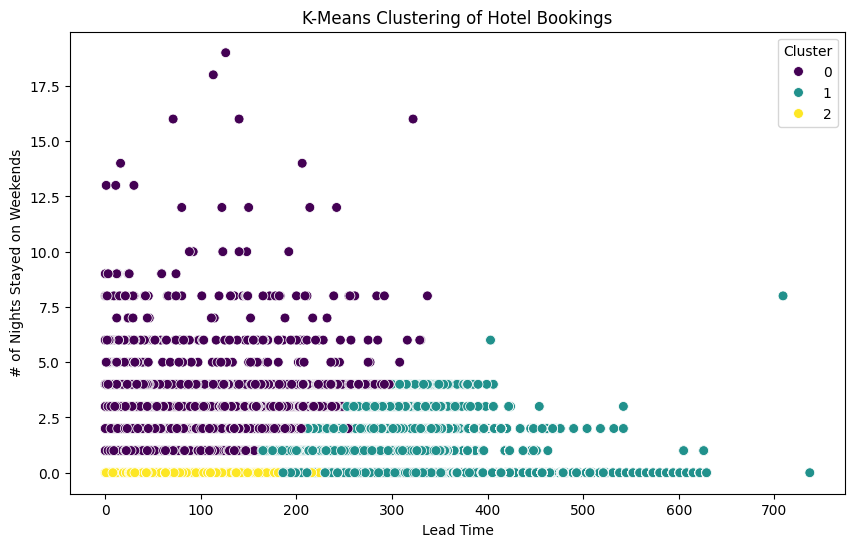

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='lead_time', y='stays_in_weekend_nights', hue='Cluster', data=df, palette='viridis', s=50)
plt.title('K-Means Clustering of Hotel Bookings')
plt.xlabel('Lead Time')
plt.ylabel('# of Nights Stayed on Weekends')
plt.show()

### ✍️ Your Response: 🔧
1. I chose a value of 3 for K. I did this because we are looking at 3 separate variables, but even more than this as we increased the number of clusters they didn't seem to make sense intuitionally. By making 3, we get 3 separate concise groupings.

2. Our yellow grouping appears to be customers with short lead time and no weekend nights stayed. Our purple grouping appears to be those with shorter lead time (compared to green) and had at least one night stayed on the weekend. Then finally we have green which is our customers with long lead times and a variety of weekend nights stayed but less than purple on average.


## 4. Apply Gaussian Mixture Model (GMM)

Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


In [27]:
from sklearn.mixture import GaussianMixture

# Fit a GMM with the same number of clusters (k=3)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

# Predict soft clusters (probabilities)
gmm_probs = gmm.predict_proba(X_scaled)

# You can optionally add the probabilities to the dataframe if needed for further analysis
# For example, adding the probability of belonging to the first cluster
# df['GMM_Cluster_Prob_0'] = gmm_probs[:, 0]

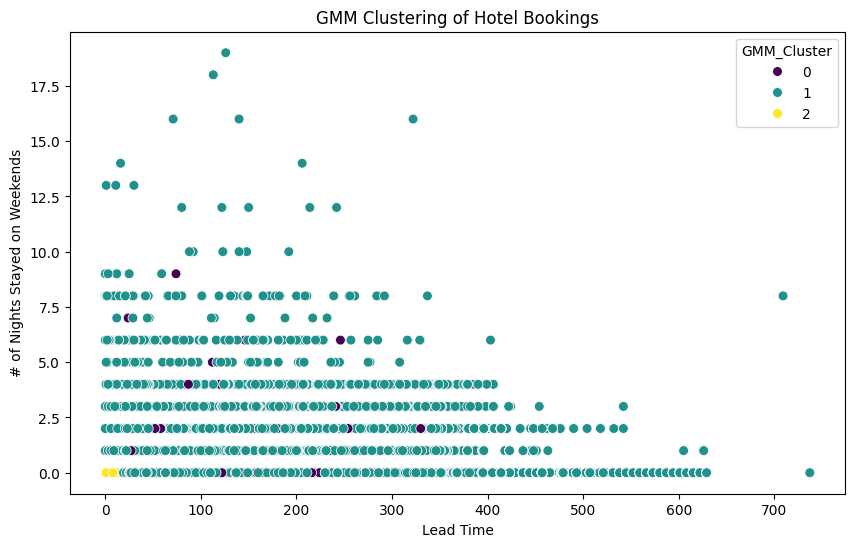

In [28]:
# Predict the cluster labels for visualization
gmm_labels = gmm.predict(X_scaled)
df['GMM_Cluster'] = gmm_labels

plt.figure(figsize=(10, 6))
sns.scatterplot(x='lead_time', y='stays_in_weekend_nights', hue='GMM_Cluster', data=df, palette='viridis', s=50)
plt.title('GMM Clustering of Hotel Bookings')
plt.xlabel('Lead Time')
plt.ylabel('# of Nights Stayed on Weekends')
plt.show()

### ✍️ Your Response: 🔧
1. With GMM our groupings are much much smaller with less variety. The majority of our clusters are the green group or group 1. Compared to the KMeans our output looks worse and likely would need further manipulation to be usable.

2. GMM might be better used when we are looking for variety among customers as they can belong to multiple clusters. For example, it may be more useful if we were looking at the $ amount paid for meals while staying at the hotel or how much a customer will spend on movies while staying.


## 5. Evaluate Your Models

Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

- Calculate:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index
- Compare both models

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [47]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate WCSS for KMeans
wcss = kmeans.inertia_
print(f'KMeans WCSS: {wcss}')

silhouette_avg_kmeans = silhouette_score(X_scaled[subset], df['Cluster'].iloc[subset])
print(f'KMeans Silhouette Score (sampled): {silhouette_avg_kmeans:.3f}')

# Calculate Davies-Bouldin Index for KMeans
db_index_kmeans = davies_bouldin_score(X_scaled, df['Cluster'])
print(f'KMeans Davies-Bouldin Index: {db_index_kmeans}')

print("-" * 20)

gmm_labels = df['GMM_Cluster']

# Get cluster centers (means) from GMM
gmm_centers = gmm.means_

# Calculate approximate WCSS (sum of squared distances to assigned cluster mean)
wcss_gmm = np.sum([
    np.sum((X_scaled[gmm_labels == i] - gmm_centers[i]) ** 2)
    for i in range(gmm.n_components)
])

print(f'GMM Approximate WCSS: {wcss_gmm:.3f}')

silhouette_avg_gmm = silhouette_score(X_scaled[subset], df['GMM_Cluster'].iloc[subset])
print(f'GMM Silhouette Score (sampled): {silhouette_avg_gmm:.3f}')

# Calculate Davies-Bouldin Index for GMM
db_index_gmm = davies_bouldin_score(X_scaled, df['GMM_Cluster'])
print(f'GMM Davies-Bouldin Index: {db_index_gmm}')

KMeans WCSS: 210476.33780385877
KMeans Silhouette Score (sampled): 0.385
KMeans Davies-Bouldin Index: 1.0748819336117048
--------------------
GMM Approximate WCSS: 243122.444
GMM Silhouette Score (sampled): 0.210
GMM Davies-Bouldin Index: 1.1206132410653897


### ✍️ Your Response: 🔧
1. It appears that when looking at all of the provided metrics KMeans performed better. It has a lower WCSS, a greater silhouette score, and a lower Davies-Bouldin.

2. When we are looking to find clear clustering and segmentation it would be better to use KMeans opposed to GMM, as we return more accurate metrics therefore, giving us improved analysis and metrics.


## 6. Business Interpretation

Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

- Review characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Think from a marketing or hotel operations perspective

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [55]:
# Group by feature_cluster and calculate the average of the specified columns
cluster_averages = df.groupby('Cluster')[['stays_in_weekend_nights', 'lead_time', 'required_car_parking_spaces']].mean()

# Display the calculated averages
print("Average values for KMeans cluster:")
display(cluster_averages)

Average values for KMeans cluster:


,stays_in_weekend_nights,lead_time,required_car_parking_spaces
Cluster,,,
0,1.678569,71.302384,0.070843
1,0.849368,281.952598,0.008822
2,0.000142,50.090793,0.080784


In [54]:
# Group by feature_cluster and calculate the average of the specified columns
cluster_averages = df.groupby('GMM_Cluster')[['stays_in_weekend_nights', 'lead_time', 'required_car_parking_spaces']].mean()

# Display the calculated averages
print("Average values for GMM cluster:")
display(cluster_averages)

Average values for GMM cluster:


,stays_in_weekend_nights,lead_time,required_car_parking_spaces
GMM_Cluster,,,
0,1.263864,78.474474,1.006807
1,1.060750,121.439026,0.000000
2,0.000000,4.392398,0.152732


### ✍️ Your Response: 🔧
1. Our "0" cluster represents those with a greater weekend night stays on average. The "1" cluster represents those with long lead times. Then our "2" cluster represents those with none or almost no weekend night stays but still had a greater need for parking spaces.

2. Our "0" cluster a hotel should appeal to their weekend stays by offering activity bundles or discounts. For "1" the hotel should offer a greater discount for booking ahead of time. Then for "2" a hotel should advertise last minute openings with an emphasis on available parking.

## 7. Final Reflection

Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The most challenging part is making educated guesses on groupings or clustering. There really isn't a definitive answer that we need to use for number of groupings so it is up to personal judgment while being able to cover all facets of our data.

2. We would use clustering when we don't know exactly what we might be looking for or if want to find out which variables may be related. When there is a lack of direction we would use clustering and unsupervised learning.

3. I would explain the clusters as types or groups of people. As we know each and every person's habits are different, by clustering we begin to sort people into groups.

4. When looking at crypto currency and the blockchain as a whole it may be very hard to determine what variables may affect each other, especially with a lack of personally identifiable information. Rather it may be easier to group people or "wallets" into clusters and begin to analyze habits and spending on a broader scale.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [56]:
!jupyter nbconvert --to html "assignment_09_PetersonSteven.ipynb"

[NbConvertApp] Converting notebook assignment_09_PetersonSteven.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 635045 bytes to assignment_09_PetersonSteven.html
